In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt
import joblib

# Define Functions

In [ ]:
def mask_data(df, mask): #Berfungsi untuk memfilter data berdasarkan waktu atau altitude
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    before_mask = len(df)
    if mask == "time":
        df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
        df["datetime_wib"] = df["datetime"].dt.tz_convert("Asia/Jakarta")
        hour = df["datetime_wib"].dt.hour
        mask = (hour >= 7) & (hour <= 17)
        df.drop(columns=["datetime", "datetime_wib"], inplace=True)
        df_filtered = df.loc[mask].reset_index(drop=True)
    elif mask == "altitude":
        mask = (df["altitude_deg"] >= 0)
        df_filtered = df.loc[mask].reset_index(drop=True)
    after_mask = len(df_filtered)
    print(f"Data sebelum masking: {before_mask}, setelah masking: {after_mask}")
    return df_filtered

In [ ]:
def evaluation_metrics(y_test, y_pred, label="Model"): #Berfungsi untuk menghitung metrik evaluasi model
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"\n=== Evaluation Results {label} ===")
    print(f"MSE  = {mse:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"R2   = {r2:.4f}")
    return mse, rmse, mae, r2

def preprocessing_altitude(df): #Berfungsi untuk mengkonversi timestamp ke fitur siklik
    df = df.sort_values("timestamp").reset_index(drop=True)
    df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    df["datetime_wib"] = df["datetime"].dt.tz_convert("Asia/Jakarta")
    hour = df["datetime_wib"].dt.hour + df["datetime_wib"].dt.minute / 60
    df["sin_hour"] = np.sin(2 * np.pi * hour / 24)
    df["cos_hour"] = np.cos(2 * np.pi * hour / 24)
    day = df["datetime_wib"].dt.day_of_year
    df["sin_day"] = np.sin(2 * np.pi * day / 365)
    df["cos_day"] = np.cos(2 * np.pi * day / 365)
    return df

def preprocessing_azimuth(df): #Berfungsi untuk mengkonversi timestamp ke fitur siklik dan azimuth ke azimutih sin-cos
    df = df.sort_values("timestamp").reset_index(drop=True)
    df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    df["datetime_wib"] = df["datetime"].dt.tz_convert("Asia/Jakarta")
    hour = df["datetime_wib"].dt.hour + df["datetime_wib"].dt.minute/60
    df["sin_hour"] = np.sin(2 * np.pi * hour / 24)
    df["cos_hour"] = np.cos(2 * np.pi * hour / 24)
    doy = df["datetime_wib"].dt.day_of_year
    df["sin_day"] = np.sin(2 * np.pi * doy / 365)
    df["cos_day"] = np.cos(2 * np.pi * doy / 365)
    df["azi_rad"] = np.deg2rad(df["azimuth_deg"])
    df["azi_sin"] = np.sin(df["azi_rad"])
    df["azi_cos"] = np.cos(df["azi_rad"])
    return df

In [85]:
def append_evaluation_data(
    results_dict,
    model_group,
    model_label,
    mse,
    rmse,
    mae,
    r2
):
    """
    Menambahkan hasil evaluasi ke grup model Random Forest

    Parameters
    ----------
    results_dict : dict
        Dictionary penyimpan hasil evaluasi
    model_group : str
        Contoh: 'rf_alt_current'
    model_label : str
        Nama eksperimen/model (contoh: 'RF depth=16')
    mse, rmse, mae, r2 : float
        Nilai metrik evaluasi
    """

    if model_group not in results_dict:
        raise ValueError(f"Model group '{model_group}' tidak ditemukan")

    results_dict[model_group]["model"] = [model_label]
    results_dict[model_group]["mse"] = [round(float(mse), 4)]
    results_dict[model_group]["rmse"] = [round(float(rmse), 4)]
    results_dict[model_group]["mae"] = [round(float(mae), 4)]
    results_dict[model_group]["r2"] = [round(float(r2), 4)]

# LSTM

In [98]:
evaluation_results_lstm = {
    "lstm_alt_current": {
        "model": [],
        "mse": [],
        "rmse": [],
        "mae": [],
        "r2": []
    },
    "lstm_azi_current": {
        "model": [],
        "mse": [],
        "rmse": [],
        "mae": [],
        "r2": []
    },
    "lstm_alt_no_current": {
        "model": [],
        "mse": [],
        "rmse": [],
        "mae": [],
        "r2": []
    },
    "lstm_azi_no_current": {
        "model": [],
        "mse": [],
        "rmse": [],
        "mae": [],
        "r2": []
    }
}


## Altitude

In [ ]:
import numpy as np
import pandas as pd
import joblib

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("data/final_data.csv")
df = mask_data(df, mask='time')
df = preprocessing_altitude(df)
# PILIH FITUR & TARGET
FEATURES = [
    "sin_hour", "cos_hour",
    "sin_day", "cos_day",
    "temperature", "humidity", "current"
]
TARGET = "altitude_deg"
X = df[FEATURES].values
y = df[TARGET].values
# NORMALISASI
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# MEMBENTUK SEQUENCE (WINDOWING)
def create_sequence(X, y, window):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i + window])
        y_seq.append(y[i + window])
    return np.array(X_seq), np.array(y_seq)
WINDOW = 20
X_seq, y_seq = create_sequence(X_scaled, y, WINDOW)
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
# TRAIN–TEST SPLIT (TIME-AWARE)
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.3,
    shuffle=False
)
# ARSITEKTUR LSTM
model = Sequential([
    LSTM(
        64,
        activation="tanh",
        input_shape=(WINDOW, X_seq.shape[2])
    ),
    Dense(32, activation="relu"),
    Dense(1)
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)
model.summary()
# TRAINING
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
# EVALUASI
y_pred = model.predict(X_test).flatten()
mse, rmse, mae, r2 = evaluation_metrics(y_test, y_pred, label="Model LSTM Altitude")
append_evaluation_data(
    evaluation_results_lstm,
    model_group="lstm_alt_current",
    model_label="",
    mse=mse,
    rmse=rmse,
    mae=mae,
    r2=r2
)
# SIMPAN MODEL
joblib.dump(scaler, "models/scaler_lstm_altitude.pkl")
model.save("models/model_lstm_altitude.h5")

Data sebelum masking: 49176, setelah masking: 22539
X_seq shape: (22519, 20, 7)
y_seq shape: (22519,)


/Users/hamdi/miniconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 728.8201 - val_loss: 438.2609
Epoch 2/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 385.6255 - val_loss: 213.4276
Epoch 3/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 45.5155 - val_loss: 13.4115
Epoch 4/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8882 - val_loss: 4.1155
Epoch 5/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.2766 - val_loss: 1.8222
Epoch 6/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1707 - val_loss: 1.2668
Epoch 7/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6285 - val_loss: 0.6355
Epoch 8/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4541 - val_loss: 0.2552
Epoch 9/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3090 - val_loss: 0.2036
Epoch 10/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2322 - val_loss: 0.2526
Epoch 11/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2369 - val_loss: 0.2280
Epoch 12/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2


=== Evaluation Results Model LSTM Altitude ===
MSE  = 0.0295
RMSE = 0.1716
MAE  = 0.1333
R2   = 0.9999


## Azimuth 2

In [100]:
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/final_data.csv")
df = mask_data(df, mask='time')
df = preprocessing_azimuth(df)

# ===============================================================
# 4. FITUR LSTM
# ===============================================================
FEATURES = [
    "temperature", "humidity", "current",
    "sin_hour", "cos_hour",
    "sin_day", "cos_day"
]

X = df[FEATURES].values
y_sin = df["azi_sin"].values
y_cos = df["azi_cos"].values

# ===============================================================
# 5. SCALING FITUR
# ===============================================================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ===============================================================
# 6. BENTUK SEQUENCE UNTUK LSTM
# ===============================================================
WINDOW = 20  # sesuaikan dengan kebutuhan model

def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

# Sequence untuk dua target berbeda
X_sin, y_sin_seq = create_sequences(X_scaled, y_sin, WINDOW)
X_cos, y_cos_seq = create_sequences(X_scaled, y_cos, WINDOW)

# ===============================================================
# 7. SPLIT DATA
# ===============================================================
X_train_sin, X_test_sin, y_sin_train, y_sin_test = train_test_split(
    X_sin, y_sin_seq, test_size=0.3, random_state=42
)
X_train_cos, X_test_cos, y_cos_train, y_cos_test = train_test_split(
    X_cos, y_cos_seq, test_size=0.3, random_state=42
)

# ===============================================================
# 8. BANGUN MODEL LSTM
# ===============================================================
def build_lstm():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW, X_scaled.shape[1])),
        Dropout(0.2),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

model_sin = build_lstm()
model_cos = build_lstm()

print("✔ Models created")

# ===============================================================
# 9. TRAIN MODEL
# ===============================================================
model_sin.fit(X_train_sin, y_sin_train, epochs=20, batch_size=32, validation_split=0.1)
model_cos.fit(X_train_cos, y_cos_train, epochs=20, batch_size=32, validation_split=0.1)

print("✔ Training selesai")

# ===============================================================
# 10. SIMPAN MODEL
# ===============================================================


# ===============================================================
# 11. PREDIKSI
# ===============================================================
y_sin_pred = model_sin.predict(X_test_sin).flatten()
y_cos_pred = model_cos.predict(X_test_cos).flatten()

# ===============================================================
# 12. REKONSTRUKSI AZIMUTH KE DERAJAT
# ===============================================================
azi_pred_rad = np.arctan2(y_sin_pred, y_cos_pred)
azi_pred_deg = (np.degrees(azi_pred_rad) + 360) % 360

azi_true_rad = np.arctan2(y_sin_test, y_cos_test)
azi_true_deg = (np.degrees(azi_true_rad) + 360) % 360

mse, rmse, mae, r2 = evaluation_metrics(azi_true_deg, azi_pred_deg,label='Evaluation Results Model LSTM Azimuth')
append_evaluation_data(
    evaluation_results_lstm,
    model_group="lstm_azi_current",
    model_label="",
    mse=mse,
    rmse=rmse,
    mae=mae,
    r2=r2
)


model_sin.save("models/model_lstm_azimuth_sin.h5")
model_cos.save("models/model_lstm_azimuth_cos.h5")
joblib.dump(scaler, "models/scaler_lstm_azimuth.pkl")

Data sebelum masking: 49176, setelah masking: 22539
✔ Models created
Epoch 1/20


/Users/hamdi/miniconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1083 - val_loss: 0.0079
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0073 - val_loss: 0.0023
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0037 - val_loss: 0.0018
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0029 - val_loss: 0.0015
Epoch 5/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 6/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0025 - val_loss: 0.0039
Epoch 7/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 8/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0019 - val_loss: 0.0562
Epoch 9/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0028 - val_loss: 8.1705e-04
Epoch 10/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0020 - val_loss: 6.7105e-04
Epoch 11/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0012 - val_loss: 8.4973e-04
Epoch 12/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/st


=== Evaluation Results Evaluation Results Model LSTM Azimuth ===
MSE  = 41.6851
RMSE = 6.4564
MAE  = 1.4601
R2   = 0.9962


['models/scaler_lstm_azimuth.pkl']

## Without Current Model

### Altitude

In [115]:
import numpy as np
import pandas as pd
import joblib

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


df = pd.read_csv("data/final_data.csv")
df = mask_data(df, mask='time')
df = preprocessing_altitude(df)

# ===============================================================
# 3. PILIH FITUR & TARGET (TANPA CURRENT)
# ===============================================================
FEATURES = [
    "sin_hour", "cos_hour",
    "sin_day", "cos_day",
    "temperature", "humidity"
]

TARGET = "altitude_deg"

X = df[FEATURES].values
y = df[TARGET].values

# ===============================================================
# 4. NORMALISASI DATA
# ===============================================================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# ===============================================================
# 5. MEMBENTUK SEQUENCE (WINDOWING)
# ===============================================================
def create_sequence(X, y, window):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i + window])
        y_seq.append(y[i + window])
    return np.array(X_seq), np.array(y_seq)

WINDOW = 20

X_seq, y_seq = create_sequence(X_scaled, y, WINDOW)

print("Shape X_seq:", X_seq.shape)
print("Shape y_seq:", y_seq.shape)

# ===============================================================
# 6. TRAIN–TEST SPLIT (TIME-AWARE)
# ===============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.3,
    shuffle=False
)

# ===============================================================
# 7. ARSITEKTUR LSTM
# ===============================================================
model = Sequential([
    LSTM(
        64,
        activation="tanh",
        input_shape=(WINDOW, X_seq.shape[2])
    ),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

model.summary()

# ===============================================================
# 8. TRAINING
# ===============================================================
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.3,
    verbose=1
)

# ===============================================================
# 9. EVALUASI
# ===============================================================


y_pred = model.predict(X_test).flatten()


mse, rmse, mae, r2 = evaluation_metrics(y_test, y_pred, label="Model LSTM Altitude No Current")
append_evaluation_data(
    evaluation_results_lstm,
    model_group="lstm_alt_no_current",
    model_label="",
    mse=mse,
    rmse=rmse,
    mae=mae,
    r2=r2
)


joblib.dump(scaler, "models/scaler_lstm_altitude_no_current.pkl")
print("✔ Scaler saved")
model.save("models/model_lstm_altitude_no_current.h5")
print("✔ Model saved as model_lstm_altitude_no_current.h5")

Data sebelum masking: 49176, setelah masking: 22539
Shape X_seq: (22519, 20, 6)
Shape y_seq: (22519,)


/Users/hamdi/miniconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 703.3834 - val_loss: 446.4326
Epoch 2/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 411.0275 - val_loss: 338.4288
Epoch 3/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 105.2011 - val_loss: 15.1889
Epoch 4/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.4296 - val_loss: 5.8198
Epoch 5/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.4595 - val_loss: 1.3727
Epoch 6/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8417 - val_loss: 0.8769
Epoch 7/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5687 - val_loss: 0.4705
Epoch 8/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3984 - val_loss: 0.4220
Epoch 9/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2470 - val_loss: 0.2602
Epoch 10/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2144 - val_loss: 0.3644
Epoch 11/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1946 - val_loss: 0.2309
Epoch 12/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 


=== Evaluation Results Model LSTM Altitude No Current ===
MSE  = 0.0383
RMSE = 0.1958
MAE  = 0.1570
R2   = 0.9999
✔ Scaler saved
✔ Model saved as model_lstm_altitude_no_current.h5


### Azimuth

In [102]:
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ===============================================================
# 1. LOAD DATA
# ===============================================================
df = pd.read_csv("data/final_data.csv")
df = mask_data(df, mask='time')
df = preprocessing_azimuth(df)
# ===============================================================
# 4. FITUR LSTM
# ===============================================================
FEATURES = [
    "temperature", "humidity",
    "sin_hour", "cos_hour",
    "sin_day", "cos_day"
]

X = df[FEATURES].values
y_sin = df["azi_sin"].values
y_cos = df["azi_cos"].values

# ===============================================================
# 5. SCALING FITUR
# ===============================================================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# ===============================================================
# 6. BENTUK SEQUENCE UNTUK LSTM
# ===============================================================
WINDOW = 20  # sesuaikan dengan kebutuhan model

def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

# Sequence untuk dua target berbeda
X_sin, y_sin_seq = create_sequences(X_scaled, y_sin, WINDOW)
X_cos, y_cos_seq = create_sequences(X_scaled, y_cos, WINDOW)

# ===============================================================
# 7. SPLIT DATA
# ===============================================================
X_train_sin, X_test_sin, y_sin_train, y_sin_test = train_test_split(
    X_sin, y_sin_seq, test_size=0.3, random_state=42
)
X_train_cos, X_test_cos, y_cos_train, y_cos_test = train_test_split(
    X_cos, y_cos_seq, test_size=0.3, random_state=42
)

# ===============================================================
# 8. BANGUN MODEL LSTM
# ===============================================================
def build_lstm():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(WINDOW, X_scaled.shape[1])),
        Dropout(0.2),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

model_sin = build_lstm()
model_cos = build_lstm()

print("✔ Models created")

# ===============================================================
# 9. TRAIN MODEL
# ===============================================================
model_sin.fit(X_train_sin, y_sin_train, epochs=20, batch_size=32, validation_split=0.1)
model_cos.fit(X_train_cos, y_cos_train, epochs=20, batch_size=32, validation_split=0.1)

print("✔ Training selesai")


# ===============================================================
# 11. PREDIKSI
# ===============================================================
y_sin_pred = model_sin.predict(X_test_sin).flatten()
y_cos_pred = model_cos.predict(X_test_cos).flatten()

# ===============================================================
# 12. REKONSTRUKSI AZIMUTH KE DERAJAT
# ===============================================================
azi_pred_rad = np.arctan2(y_sin_pred, y_cos_pred)
azi_pred_deg = (np.degrees(azi_pred_rad) + 360) % 360

azi_true_rad = np.arctan2(y_sin_test, y_cos_test)
azi_true_deg = (np.degrees(azi_true_rad) + 360) % 360

mse, rmse, mae, r2 = evaluation_metrics(azi_true_deg, azi_pred_deg, label="Model LSTM Azimuth No Current")
append_evaluation_data(
    evaluation_results_lstm,
    model_group="lstm_azi_no_current",
    model_label="",
    mse=mse,
    rmse=rmse,
    mae=mae,
    r2=r2
)

joblib.dump(scaler, "models/scaler_lstm_azimuth_no_current.pkl")
model_sin.save("models/model_lstm_azimuth_sin_no_current.h5")
model_cos.save("models/model_lstm_azimuth_cos_no_current.h5")

print("✔ Model saved (sin & cos)")
print("✔ Scaler saved as scaler_lstm_azimuth_no_current.pkl")

Data sebelum masking: 49176, setelah masking: 22539
✔ Models created
Epoch 1/20


/Users/hamdi/miniconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1199 - val_loss: 0.0133
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0101 - val_loss: 0.0029
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0064 - val_loss: 0.0039
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0032 - val_loss: 0.0017
Epoch 5/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 6/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0050 - val_loss: 9.5730e-04
Epoch 7/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0018 - val_loss: 0.0021
Epoch 8/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 9/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0015 - val_loss: 8.9973e-04
Epoch 10/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0023 - val_loss: 7.4084e-04
Epoch 11/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0061 - val_loss: 0.0126
Epoch 12/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/ste


=== Evaluation Results Model LSTM Azimuth No Current ===
MSE  = 80.0821
RMSE = 8.9489
MAE  = 1.3353
R2   = 0.9927


✔ Model saved (sin & cos)
✔ Scaler saved as scaler_lstm_azimuth_no_current.pkl


## Evaluate

In [103]:
evaluation_results_lstm

{'lstm_alt_current': {'model': [''],
  'mse': [0.0295],
  'rmse': [0.1716],
  'mae': [0.1333],
  'r2': [0.9999]},
 'lstm_azi_current': {'model': [''],
  'mse': [41.6851],
  'rmse': [6.4564],
  'mae': [1.4601],
  'r2': [0.9962]},
 'lstm_alt_no_current': {'model': [''],
  'mse': [0.0334],
  'rmse': [0.1828],
  'mae': [0.1385],
  'r2': [0.9999]},
 'lstm_azi_no_current': {'model': [''],
  'mse': [80.0821],
  'rmse': [8.9489],
  'mae': [1.3353],
  'r2': [0.9927]}}

# Random Forest

In [104]:
evaluation_results_rf = {
    "rf_alt_current": {
        "model": [],
        "mse": [],
        "rmse": [],
        "mae": [],
        "r2": []
    },
    "rf_azi_current": {
        "model": [],
        "mse": [],
        "rmse": [],
        "mae": [],
        "r2": []
    },
    "rf_alt_no_current": {
        "model": [],
        "mse": [],
        "rmse": [],
        "mae": [],
        "r2": []
    },
    "rf_azi_no_current": {
        "model": [],
        "mse": [],
        "rmse": [],
        "mae": [],
        "r2": []
    }
}


## Altitude

In [105]:
import numpy as np
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===============================================================
# 1. LOAD & SORT DATA
# ===============================================================
df = pd.read_csv("data/final_data.csv")
df = mask_data(df, mask='time')
df = preprocessing_altitude(df)

# ===============================================================
# 4. PILIH FITUR & TARGET
# ===============================================================
FEATURES = [
    "sin_hour", "cos_hour", "current",
    "sin_day", "cos_day",
    "temperature", "humidity"
]

TARGET = "altitude_deg"

X = df[FEATURES].values
y = df[TARGET].values

# ===============================================================
# 5. SCALING
# ===============================================================
#scaler = StandardScaler()
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ===============================================================
# 6. TRAIN–TEST SPLIT (TIME-AWARE)
# ===============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    shuffle=False
)

# ===============================================================
# 7. RANDOM FOREST MODEL
# ===============================================================
rf = RandomForestRegressor(
    n_estimators=80,
    max_depth=12,
    min_samples_split=8,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ===============================================================
# 8. EVALUASI MODEL
# ===============================================================


y_pred = rf.predict(X_test)

mse, rmse, mae, r2 = evaluation_metrics(y_test, y_pred, label="Model LSTM Random Forest Altitude")
append_evaluation_data(
    evaluation_results_rf,
    model_group="rf_alt_current",
    model_label=f"Depth=16, n_estimators=60",
    mse=mse,
    rmse=rmse,
    mae=mae,
    r2=r2
)
# ===============================================================
# 9. SIMPAN MODEL
# ===============================================================
joblib.dump(scaler, "models/scaler_rf_altitude.pkl")
joblib.dump(rf, "models/model_rf_altitude.pkl")

Data sebelum masking: 49176, setelah masking: 22539

=== Evaluation Results Model LSTM Random Forest Altitude ===
MSE  = 0.9647
RMSE = 0.9822
MAE  = 0.6745
R2   = 0.9977


['models/model_rf_altitude.pkl']

## Azimuth 2

In [106]:
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ===============================================================
# 1. LOAD DATA
# ===============================================================
df = pd.read_csv("data/final_data.csv")
df = mask_data(df, mask='time')
df = preprocessing_azimuth(df)
# ===============================================================
# 4. FITUR UNTUK MODEL
# ===============================================================
FEATURES = [
    "temperature", "humidity", "current",
    "sin_hour", "cos_hour",
    "sin_day", "cos_day"
]

X = df[FEATURES].values
y_sin = df["azi_sin"].values
y_cos = df["azi_cos"].values

# ===============================================================
# 5. SCALING
# ===============================================================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# ===============================================================
# 6. TRAIN-TEST SPLIT
# ===============================================================
X_train, X_test, y_sin_train, y_sin_test, y_cos_train, y_cos_test = train_test_split(
    X_scaled, y_sin, y_cos, test_size=0.3, shuffle=False, random_state=42
)

# ===============================================================
# 7. TRAIN RF (SIN & COS)
# ===============================================================

rf_sin = RandomForestRegressor(
    n_estimators=80,        # ⬇️ dari 120 → setengah ukuran
    max_depth=12,           # ⬇️ depth lebih dangkal (KRUSIAL)
    min_samples_split=8,    # ⬆️ kurangi node
    min_samples_leaf=6,     # ⬆️ node lebih gemuk → jauh lebih sedikit
    max_features=0.5,       # ⬇️ subset fitur lebih kecil
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_cos = RandomForestRegressor(
    n_estimators=80,        # ⬇️ dari 120 → setengah ukuran
    max_depth=12,           # ⬇️ depth lebih dangkal (KRUSIAL)
    min_samples_split=8,    # ⬆️ kurangi node
    min_samples_leaf=6,     # ⬆️ node lebih gemuk → jauh lebih sedikit
    max_features=0.5,       # ⬇️ subset fitur lebih kecil
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)


rf_sin.fit(X_train, y_sin_train)
rf_cos.fit(X_train, y_cos_train)

print("✔ Training selesai untuk model RF sin & cos")

# ===============================================================
# 8. SAVE MODEL
# ===============================================================

# ===============================================================
# 9. PREDIKSI DAN REKONSTRUKSI AZIMUTH
# ===============================================================
y_sin_pred = rf_sin.predict(X_test)
y_cos_pred = rf_cos.predict(X_test)

# rekonversi ke derajat (0–360)
azi_pred_rad = np.arctan2(y_sin_pred, y_cos_pred)
azi_pred_deg = (np.degrees(azi_pred_rad) + 360) % 360

# sudut aktual
azi_true_deg = (np.degrees(np.arctan2(y_sin_test, y_cos_test)) + 360) % 360

# ===============================================================
# 10. CETAK CONTOH
# ===============================================================
mse, rmse, mae, r2 = evaluation_metrics(azi_true_deg, azi_pred_deg, label="Model Random Forest Azimuth")
append_evaluation_data(
    evaluation_results_rf,
    model_group="rf_azi_current",
    model_label=f"Depth=16, n_estimators=120",
    mse=mse,
    rmse=rmse,
    mae=mae,
    r2=r2
)
joblib.dump(scaler, "models/scaler_rf_azimuth.pkl")
joblib.dump(rf_sin, "models/model_rf_azimuth_sin.pkl")
joblib.dump(rf_cos, "models/model_rf_azimuth_cos.pkl")

print("✔ Model saved")
print("✔ Scaler saved")

Data sebelum masking: 49176, setelah masking: 22539
✔ Training selesai untuk model RF sin & cos

=== Evaluation Results Model Random Forest Azimuth ===
MSE  = 114.7873
RMSE = 10.7139
MAE  = 1.1083
R2   = 0.9897
✔ Model saved
✔ Scaler saved


## Without Current Model

### Altitude

In [ ]:
import numpy as np
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===============================================================
# 1. URUTKAN DATA BERDASARKAN WAKTU
# ===============================================================
df = pd.read_csv("data/final_data.csv")
df = mask_data(df, mask='time')
df = preprocessing_altitude(df)

# ===============================================================
# 3. PILIH FITUR & TARGET (TANPA CURRENT)
# ===============================================================
FEATURES = [
    "sin_hour", "cos_hour",
    "sin_day", "cos_day",
    "temperature", "humidity"
]

TARGET = "altitude_deg"

X = df[FEATURES].values
y = df[TARGET].values

# ===============================================================
# 4. NORMALISASI
# ===============================================================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# ===============================================================
# 5. TRAIN–TEST SPLIT (TIME-AWARE)
# ===============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    shuffle=False
)

# ===============================================================
# 6. RANDOM FOREST (RINGAN + AKURAT)
# ===============================================================
rf = RandomForestRegressor(
    n_estimators=80,
    max_depth=12,
    min_samples_split=8,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ===============================================================
# 7. PREDIKSI & EVALUASI
# ===============================================================
y_pred = rf.predict(X_test)
mse, rmse, mae, r2 = evaluation_metrics(y_test, y_pred, label="Model Random Forest Altitude No Current")
append_evaluation_data(
    evaluation_results_rf,
    model_group="rf_alt_no_current",
    model_label=f"Depth=14, n_estimators=60",
    mse=mse,
    rmse=rmse,
    mae=mae,
    r2=r2
)
# ===============================================================
# 8. SIMPAN MODEL
# ===============================================================
joblib.dump(rf, "models/model_rf_altitude_no_current.pkl")
joblib.dump(scaler, "models/scaler_rf_altitude_no_current.pkl")

Data sebelum masking: 49176, setelah masking: 22539

=== Evaluation Results Model Random Forest Altitude No Current ===
MSE  = 0.6555
RMSE = 0.8096
MAE  = 0.5527
R2   = 0.9985


['models/scaler_rf_altitude_no_current.pkl']

### Azimuth

In [108]:
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ===============================================================
# 1. LOAD DATA
# ===============================================================
df = pd.read_csv("data/final_data.csv")
df = mask_data(df, mask='time')
df = preprocessing_azimuth(df)

# ===============================================================
# 4. FITUR UNTUK MODEL
# ===============================================================
FEATURES = [
    "temperature", "humidity",
    "sin_hour", "cos_hour",
    "sin_day", "cos_day"
]

X = df[FEATURES].values
y_sin = df["azi_sin"].values
y_cos = df["azi_cos"].values

# ===============================================================
# 5. SCALING
# ===============================================================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("✔ Scaler saved as scaler_rf_azimuth_no_current.pkl")

# ===============================================================
# 6. TRAIN-TEST SPLIT
# ===============================================================
X_train, X_test, y_sin_train, y_sin_test, y_cos_train, y_cos_test = train_test_split(
    X_scaled, y_sin, y_cos, test_size=0.3, shuffle=True, random_state=42
)

# ===============================================================
# 7. TRAIN RF (SIN & COS)
# ===============================================================


rf_sin = RandomForestRegressor(
    n_estimators=80,        # ⬇️ dari 120 → setengah ukuran
    max_depth=12,           # ⬇️ depth lebih dangkal (KRUSIAL)
    min_samples_split=8,    # ⬆️ kurangi node
    min_samples_leaf=6,     # ⬆️ node lebih gemuk → jauh lebih sedikit
    max_features=0.5,       # ⬇️ subset fitur lebih kecil
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_cos = RandomForestRegressor(
    n_estimators=80,        # ⬇️ dari 120 → setengah ukuran
    max_depth=12,           # ⬇️ depth lebih dangkal (KRUSIAL)
    min_samples_split=8,    # ⬆️ kurangi node
    min_samples_leaf=6,     # ⬆️ node lebih gemuk → jauh lebih sedikit
    max_features=0.5,       # ⬇️ subset fitur lebih kecil
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)



rf_sin.fit(X_train, y_sin_train)
rf_cos.fit(X_train, y_cos_train)

print("✔ Training selesai untuk model RF sin & cos")



# ===============================================================
# 9. PREDIKSI DAN REKONSTRUKSI AZIMUTH
# ===============================================================
y_sin_pred = rf_sin.predict(X_test)
y_cos_pred = rf_cos.predict(X_test)

# rekonversi ke derajat (0–360)
azi_pred_rad = np.arctan2(y_sin_pred, y_cos_pred)
azi_pred_deg = (np.degrees(azi_pred_rad) + 360) % 360

# sudut aktual
azi_true_deg = (np.degrees(np.arctan2(y_sin_test, y_cos_test)) + 360) % 360

mse, rmse, mae, r2 = evaluation_metrics(azi_true_deg, azi_pred_deg, label="Model Random Forest Altitude No Current")
append_evaluation_data(
    evaluation_results_rf,
    model_group="rf_azi_no_current",
    model_label=f"Depth=16, n_estimators=60",
    mse=mse,
    rmse=rmse,
    mae=mae,
    r2=r2
)

joblib.dump(rf_sin, "models/model_rf_azimuth_sin_no_current.pkl")
joblib.dump(rf_cos, "models/model_rf_azimuth_cos_no_current.pkl")
joblib.dump(scaler, "models/scaler_rf_azimuth_no_current.pkl")

print("✔ Model saved")

Data sebelum masking: 49176, setelah masking: 22539
✔ Scaler saved as scaler_rf_azimuth_no_current.pkl
✔ Training selesai untuk model RF sin & cos

=== Evaluation Results Model Random Forest Altitude No Current ===
MSE  = 0.8305
RMSE = 0.9113
MAE  = 0.5237
R2   = 0.9999
✔ Model saved


## Evaluate

In [109]:
evaluation_results_rf

{'rf_alt_current': {'model': ['Depth=16, n_estimators=60'],
  'mse': [0.9647],
  'rmse': [0.9822],
  'mae': [0.6745],
  'r2': [0.9977]},
 'rf_azi_current': {'model': ['Depth=16, n_estimators=120'],
  'mse': [114.7873],
  'rmse': [10.7139],
  'mae': [1.1083],
  'r2': [0.9897]},
 'rf_alt_no_current': {'model': ['Depth=14, n_estimators=60'],
  'mse': [0.6555],
  'rmse': [0.8096],
  'mae': [0.5527],
  'r2': [0.9985]},
 'rf_azi_no_current': {'model': ['Depth=16, n_estimators=60'],
  'mse': [0.8305],
  'rmse': [0.9113],
  'mae': [0.5237],
  'r2': [0.9999]}}

# Load Model (4 Model)

In [110]:
import matplotlib.pyplot as plt

def plot_actual_predictions(y_true_alt, y_pred_alt, y_true_azi, y_pred_azi, title="Actual vs Predicted"):
    # ============================
    # 9. PLOT SCATTER
    # ============================
    plt.figure(figsize=(15, 8))
    plt.suptitle(title, fontsize=16)

    # ---------- ALTITUDE ----------
    ax1 = plt.subplot(1, 2, 1)
    ax1.scatter(y_true_alt, y_pred_alt, alpha=0.5)
    min_val = min(y_true_alt.min(), y_pred_alt.min())
    max_val = max(y_true_alt.max(), y_pred_alt.max())
    ax1.plot([min_val, max_val], [min_val, max_val], "r--")

    ax1.set_xlabel("Altitude Aktual (°)")
    ax1.set_ylabel("Altitude Prediksi (°)")
    ax1.set_title("Scatter Plot Altitude")
    ax1.grid(True, linestyle="--", alpha=0.4)

    # 👉 kunci agar PERSEGI
    ax1.set_aspect("equal", adjustable="box")

    # ---------- AZIMUTH ----------
    ax2 = plt.subplot(1, 2, 2)
    ax2.scatter(y_true_azi, y_pred_azi, alpha=0.5, color="gray")
    min_val = min(y_true_azi.min(), y_pred_azi.min())
    max_val = max(y_true_azi.max(), y_pred_azi.max())
    ax2.plot([min_val, max_val], [min_val, max_val], "r--")

    ax2.set_xlabel("Azimuth Aktual (°)")
    ax2.set_ylabel("Azimuth Prediksi (°)")
    ax2.set_title("Scatter Plot Azimuth")
    ax2.grid(True, linestyle="--", alpha=0.4)

    # 👉 kunci agar PERSEGI
    ax2.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.15)  # ⬅️ atur jarak horizontal
    plt.show()


## LSTM

### With Current

Data sebelum masking: 49176, setelah masking: 22539


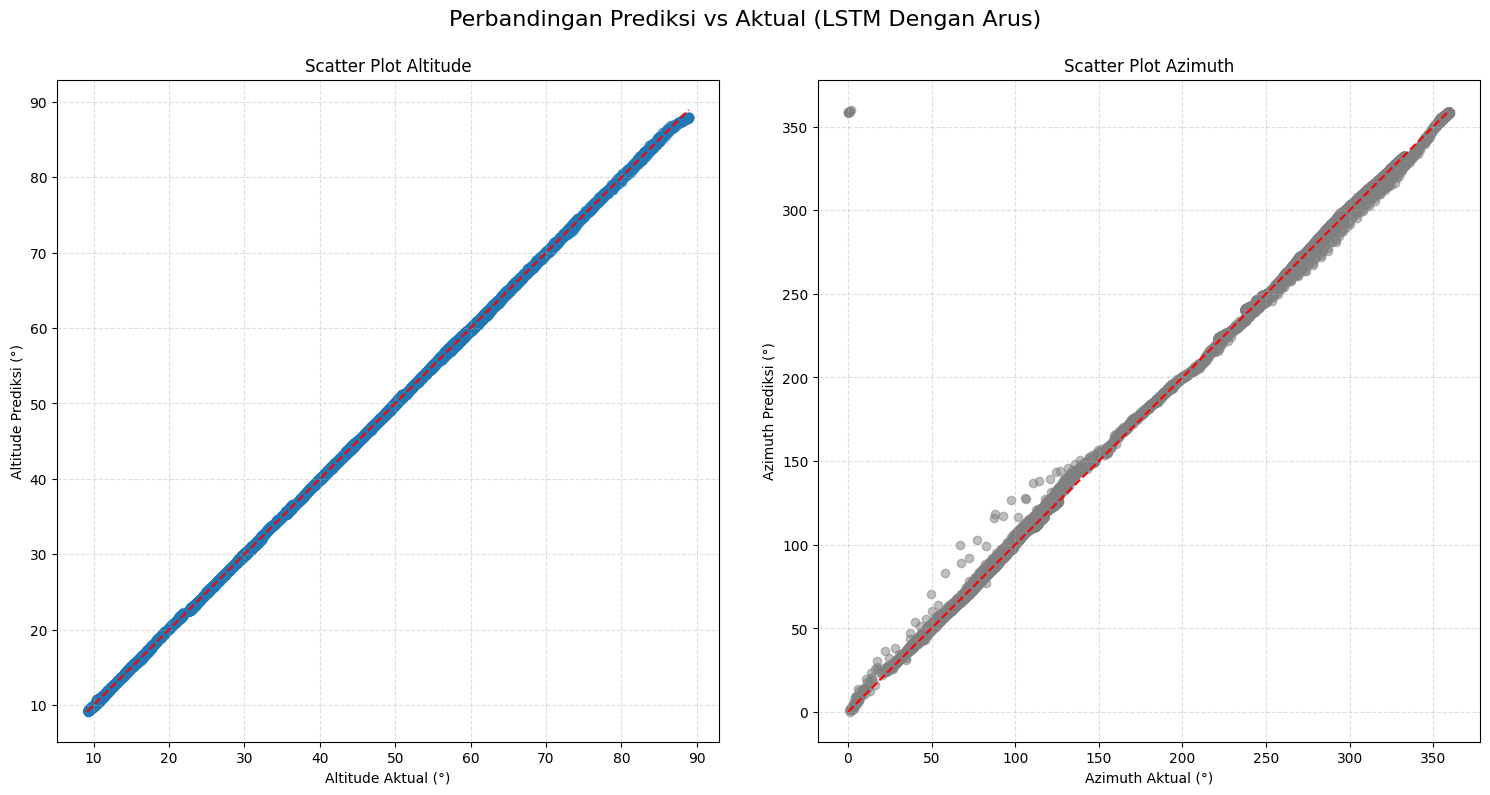

In [111]:
import numpy as np

import pandas as pd
from tensorflow.keras.models import load_model
import joblib

# ============================
# 1. LOAD MODEL & SCALER
# ============================
model_alt = load_model("models/model_lstm_altitude.h5", compile=False)

model_azi_sin = load_model("models/model_lstm_azimuth_sin.h5", compile=False)
model_azi_cos = load_model("models/model_lstm_azimuth_cos.h5", compile=False)

scaler_alt = joblib.load("models/scaler_lstm_altitude.pkl")
scaler_azi = joblib.load("models/scaler_lstm_azimuth.pkl")

WINDOW = 20

# ============================
# 2. LOAD DATASET
# ============================
df = pd.read_csv("data/final_data.csv")
df = mask_data(df,mask='time')
df["date"] = pd.to_datetime(df["date"])
df["datetime_wib"] = df["date"].dt.tz_localize("Asia/Jakarta")

# ============================
# 3. FITUR WAKTU SIKLIK
# ============================
hour = df["datetime_wib"].dt.hour + df["datetime_wib"].dt.minute / 60
df["sin_hour"] = np.sin(2 * np.pi * hour / 24)
df["cos_hour"] = np.cos(2 * np.pi * hour / 24)

doy = df["datetime_wib"].dt.day_of_year
df["sin_day"] = np.sin(2 * np.pi * doy / 365)
df["cos_day"] = np.cos(2 * np.pi * doy / 365)

# ============================
# 4. FITUR INPUT (REVISI)
# ============================
# 🔴 ALTITUDE sekarang menggunakan sin–cos waktu
FEATURES_ALT = [
    "sin_hour", "cos_hour",
    "sin_day", "cos_day",
    "temperature", "humidity", "current"
]

# 🔵 AZIMUTH tetap sin–cos
FEATURES_AZI = [
    "temperature", "humidity", "current",
    "sin_hour", "cos_hour",
    "sin_day", "cos_day"
]

X_alt = df[FEATURES_ALT].values
X_azi = df[FEATURES_AZI].values

y_true_alt = df["altitude_deg"].values
y_true_azi = df["azimuth_deg"].values

# ============================
# 5. SCALING
# ============================
X_alt_scaled = scaler_alt.transform(X_alt)
X_azi_scaled = scaler_azi.transform(X_azi)

# ============================
# 6. BENTUK SEQUENCE
# ============================
def create_sequence(X, window):
    return np.array([X[i:i + window] for i in range(len(X) - window)])

X_alt_seq = create_sequence(X_alt_scaled, WINDOW)
X_azi_seq = create_sequence(X_azi_scaled, WINDOW)

# sinkronkan target
y_true_alt = y_true_alt[WINDOW:]
y_true_azi = y_true_azi[WINDOW:]

# ============================
# 7. PREDIKSI LSTM
# ============================
y_pred_alt = model_alt.predict(X_alt_seq, verbose=0).flatten()

y_sin_pred = model_azi_sin.predict(X_azi_seq, verbose=0).flatten()
y_cos_pred = model_azi_cos.predict(X_azi_seq, verbose=0).flatten()

# ============================
# 8. REKONSTRUKSI AZIMUTH
# ============================
azi_pred_rad = np.arctan2(y_sin_pred, y_cos_pred)
y_pred_azi = (np.degrees(azi_pred_rad) + 360) % 360


plot_actual_predictions(
    y_true_alt, y_pred_alt,
    y_true_azi, y_pred_azi,
    title="Perbandingan Prediksi vs Aktual (LSTM Dengan Arus)"
)

### Without Current

Data sebelum masking: 49176, setelah masking: 22539


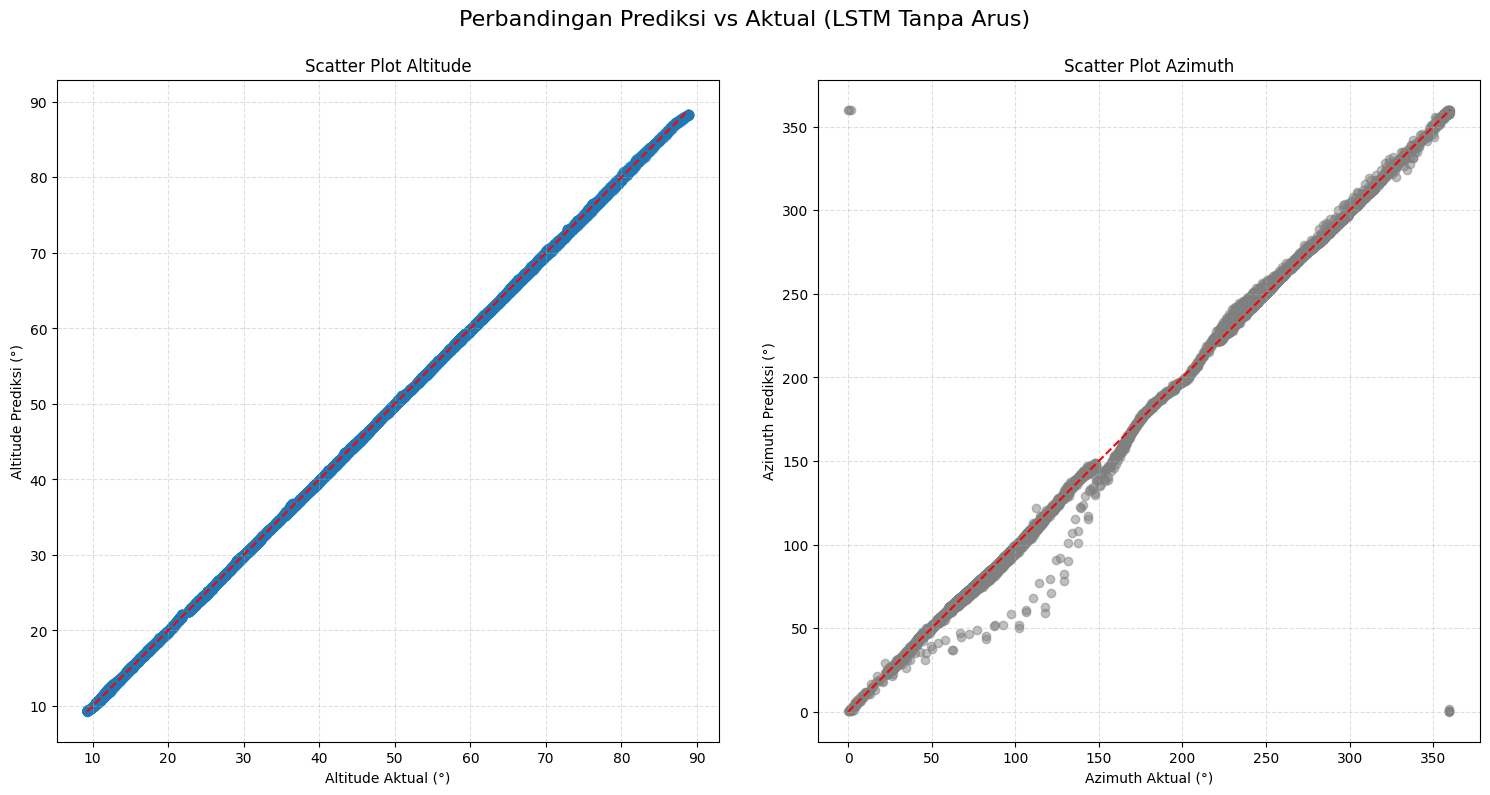

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import load_model
import joblib

# ============================
# 1. LOAD MODEL & SCALER
# ============================
model_alt = load_model("models/model_lstm_altitude_no_current.h5", compile=False)

model_azi_sin = load_model("models/model_lstm_azimuth_sin_no_current.h5", compile=False)
model_azi_cos = load_model("models/model_lstm_azimuth_cos_no_current.h5", compile=False)

scaler_alt = joblib.load("models/scaler_lstm_altitude_no_current.pkl")
scaler_azi = joblib.load("models/scaler_lstm_azimuth_no_current.pkl")

WINDOW = 20

# ============================
# 2. LOAD DATASET
# ============================
df = pd.read_csv("data/final_data.csv")
df = mask_data(df,mask='time')
df["date"] = pd.to_datetime(df["date"])
df["datetime_wib"] = df["date"].dt.tz_localize("Asia/Jakarta")

# ============================
# 3. FITUR WAKTU SIKLIK
# ============================
hour = df["datetime_wib"].dt.hour + df["datetime_wib"].dt.minute / 60
df["sin_hour"] = np.sin(2 * np.pi * hour / 24)
df["cos_hour"] = np.cos(2 * np.pi * hour / 24)

doy = df["datetime_wib"].dt.day_of_year
df["sin_day"] = np.sin(2 * np.pi * doy / 365)
df["cos_day"] = np.cos(2 * np.pi * doy / 365)

# ============================
# 4. FITUR INPUT (REVISI)
# ============================
# 🔴 ALTITUDE (no current, sin–cos time)
FEATURES_ALT = [
    "sin_hour", "cos_hour",
    "sin_day", "cos_day",
    "temperature", "humidity"
]

# 🔵 AZIMUTH (no current, sin–cos)
FEATURES_AZI = [
    "temperature", "humidity",
    "sin_hour", "cos_hour",
    "sin_day", "cos_day"
]

X_alt = df[FEATURES_ALT].values
X_azi = df[FEATURES_AZI].values

y_true_alt = df["altitude_deg"].values
y_true_azi = df["azimuth_deg"].values

# ============================
# 5. SCALING
# ============================
X_alt_scaled = scaler_alt.transform(X_alt)
X_azi_scaled = scaler_azi.transform(X_azi)

# ============================
# 6. BENTUK SEQUENCE
# ============================
def create_sequence(X, window):
    return np.array([X[i:i + window] for i in range(len(X) - window)])

X_alt_seq = create_sequence(X_alt_scaled, WINDOW)
X_azi_seq = create_sequence(X_azi_scaled, WINDOW)

# sinkronkan target
y_true_alt = y_true_alt[WINDOW:]
y_true_azi = y_true_azi[WINDOW:]

# ============================
# 7. PREDIKSI LSTM
# ============================
y_pred_alt = model_alt.predict(X_alt_seq, verbose=0).flatten()

y_sin_pred = model_azi_sin.predict(X_azi_seq, verbose=0).flatten()
y_cos_pred = model_azi_cos.predict(X_azi_seq, verbose=0).flatten()

azi_pred_rad = np.arctan2(y_sin_pred, y_cos_pred)
y_pred_azi = (np.degrees(azi_pred_rad) + 360) % 360


plot_actual_predictions(
    y_true_alt, y_pred_alt,
    y_true_azi, y_pred_azi,
    title="Perbandingan Prediksi vs Aktual (LSTM Tanpa Arus)"
)



## Random Forest

### With Current

Data sebelum masking: 49176, setelah masking: 22539


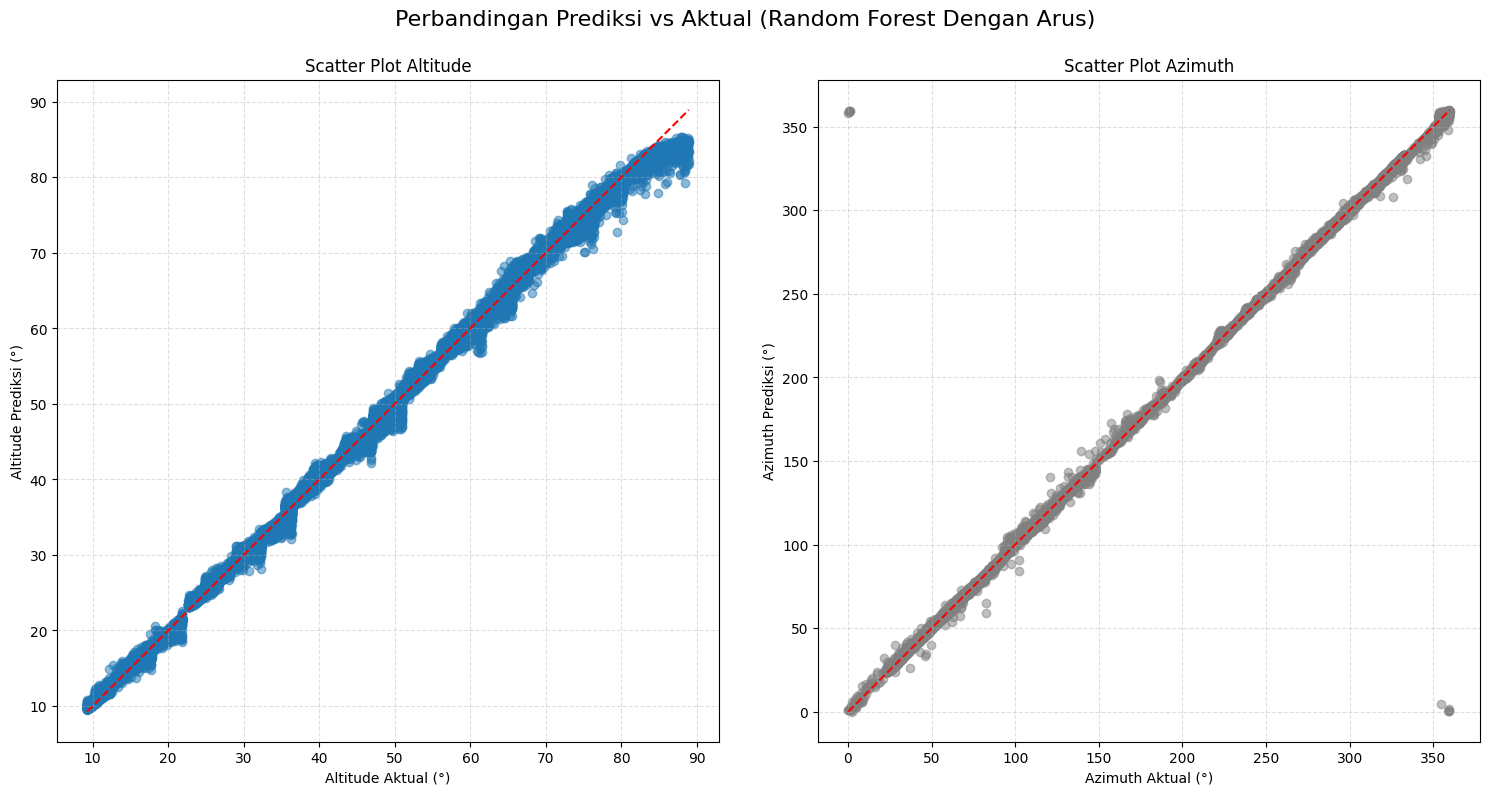

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib

# ============================
# 1. LOAD MODEL & SCALER
# ============================
model_rf_alt = joblib.load("models/model_rf_altitude.pkl")

model_rf_azi_sin = joblib.load("models/model_rf_azimuth_sin.pkl")
model_rf_azi_cos = joblib.load("models/model_rf_azimuth_cos.pkl")

scaler_rf_alt = joblib.load("models/scaler_rf_altitude.pkl")
scaler_rf_azi = joblib.load("models/scaler_rf_azimuth.pkl")

# ============================
# 2. LOAD DATASET
# ============================
df = pd.read_csv("data/final_data.csv")
df = mask_data(df,mask='time')
df["date"] = pd.to_datetime(df["date"])
df["datetime_wib"] = df["date"].dt.tz_localize("Asia/Jakarta")

# ============================
# 3. FITUR WAKTU SIKLIK
# ============================
hour = df["datetime_wib"].dt.hour + df["datetime_wib"].dt.minute / 60
df["sin_hour"] = np.sin(2 * np.pi * hour / 24)
df["cos_hour"] = np.cos(2 * np.pi * hour / 24)

doy = df["datetime_wib"].dt.day_of_year
df["sin_day"] = np.sin(2 * np.pi * doy / 365)
df["cos_day"] = np.cos(2 * np.pi * doy / 365)

# ============================
# 4. FITUR INPUT (REVISI)
# ============================
# 🔴 ALTITUDE (tanpa timestamp linear)
FEATURES_ALT = [
    "sin_hour", "cos_hour","current",
    "sin_day", "cos_day",
    "temperature", "humidity"
]

# 🔵 AZIMUTH (sin–cos)
FEATURES_AZI = [
    "temperature", "humidity","current",
    "sin_hour", "cos_hour",
    "sin_day", "cos_day"
]

X_alt = df[FEATURES_ALT].values
X_azi = df[FEATURES_AZI].values

y_true_alt = df["altitude_deg"].values
y_true_azi = df["azimuth_deg"].values

# ============================
# 5. SCALING
# ============================
X_alt_scaled = scaler_rf_alt.transform(X_alt)
X_azi_scaled = scaler_rf_azi.transform(X_azi)

# ============================
# 6. PREDIKSI RANDOM FOREST
# ============================
y_pred_alt = model_rf_alt.predict(X_alt_scaled)

y_sin_pred = model_rf_azi_sin.predict(X_azi_scaled)
y_cos_pred = model_rf_azi_cos.predict(X_azi_scaled)

# ============================
# 7. REKONSTRUKSI AZIMUTH
# ============================
azi_pred_rad = np.arctan2(y_sin_pred, y_cos_pred)
y_pred_azi = (np.degrees(azi_pred_rad) + 360) % 360

plot_actual_predictions(
    y_true_alt, y_pred_alt,
    y_true_azi, y_pred_azi,
    title="Perbandingan Prediksi vs Aktual (Random Forest Dengan Arus)"
)

### Without Current

Data sebelum masking: 49176, setelah masking: 22539


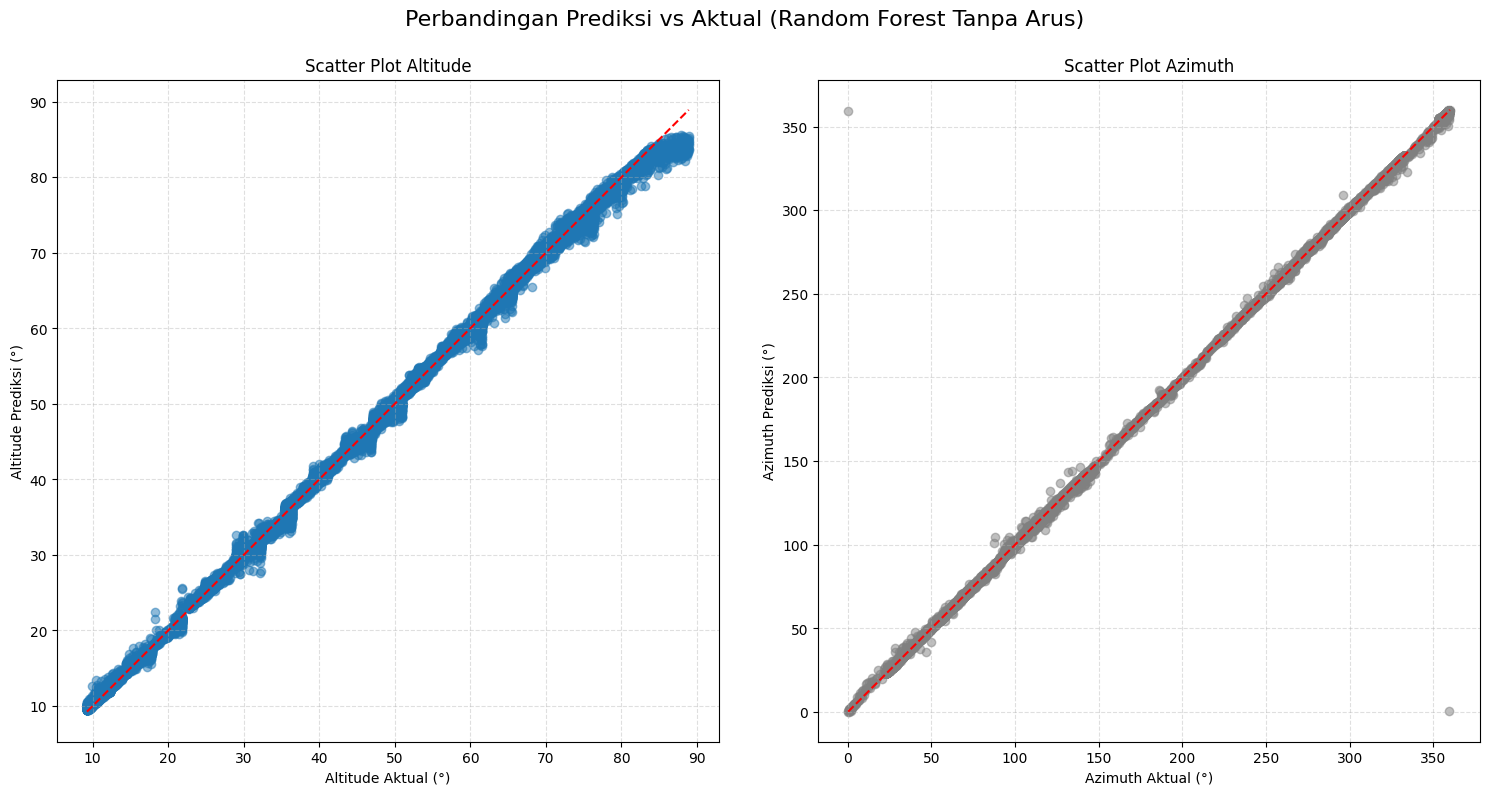

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib

# ============================
# 1. LOAD MODEL & SCALER
# ============================
model_rf_alt = joblib.load("models/model_rf_altitude_no_current.pkl")

model_rf_azi_sin = joblib.load("models/model_rf_azimuth_sin_no_current.pkl")
model_rf_azi_cos = joblib.load("models/model_rf_azimuth_cos_no_current.pkl")

scaler_rf_alt = joblib.load("models/scaler_rf_altitude_no_current.pkl")
scaler_rf_azi = joblib.load("models/scaler_rf_azimuth_no_current.pkl")

# ============================
# 2. LOAD DATASET
# ============================
df = pd.read_csv("data/final_data.csv")
df = mask_data(df,mask='time')
df["date"] = pd.to_datetime(df["date"])
df["datetime_wib"] = df["date"].dt.tz_localize("Asia/Jakarta")

# ============================
# 3. FITUR WAKTU SIKLIK
# ============================
hour = df["datetime_wib"].dt.hour + df["datetime_wib"].dt.minute / 60
df["sin_hour"] = np.sin(2 * np.pi * hour / 24)
df["cos_hour"] = np.cos(2 * np.pi * hour / 24)

doy = df["datetime_wib"].dt.day_of_year
df["sin_day"] = np.sin(2 * np.pi * doy / 365)
df["cos_day"] = np.cos(2 * np.pi * doy / 365)




# ============================
# 4. FITUR INPUT (REVISI)
# ============================
# 🔴 ALTITUDE (no current, sin–cos time)
FEATURES_ALT = [
    "sin_hour", "cos_hour",
    "sin_day", "cos_day",
    "temperature", "humidity"
]

# 🔵 AZIMUTH (sin–cos)
FEATURES_AZI = [
    "temperature", "humidity",
    "sin_hour", "cos_hour",
    "sin_day", "cos_day"
]

X_alt = df[FEATURES_ALT].values
X_azi = df[FEATURES_AZI].values

y_true_alt = df["altitude_deg"].values
y_true_azi = df["azimuth_deg"].values

# ============================
# 5. SCALING
# ============================
X_alt_scaled = scaler_rf_alt.transform(X_alt)
X_azi_scaled = scaler_rf_azi.transform(X_azi)

# ============================
# 6. PREDIKSI RANDOM FOREST
# ============================
y_pred_alt = model_rf_alt.predict(X_alt_scaled)

y_sin_pred = model_rf_azi_sin.predict(X_azi_scaled)
y_cos_pred = model_rf_azi_cos.predict(X_azi_scaled)

# ============================
# 7. REKONSTRUKSI AZIMUTH
# ============================
azi_pred_rad = np.arctan2(y_sin_pred, y_cos_pred)
y_pred_azi = (np.degrees(azi_pred_rad) + 360) % 360

plot_actual_predictions(
    y_true_alt, y_pred_alt,
    y_true_azi, y_pred_azi,
    title="Perbandingan Prediksi vs Aktual (Random Forest Tanpa Arus)"
)
